In [1]:
import sys
sys.path.append('..')
from utils.fonctions import load_parquet_data, normalize_colnames_list
from src.artifacts.data_processing import Nettoyage
from utils.fonctions import load_pickle
import numpy as np

In [14]:
df = load_parquet_data('../ressources/data/3_cleaned/2025_04_30/df_cleaned_encoded_with_use_target_correlation_selection.parquet')


Loading parquet data from : ../ressources/data/3_cleaned/2025_04_30/df_cleaned_encoded_with_use_target_correlation_selection.parquet..


In [15]:
# decision tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error

TARGET_COL = 'conso_kwh_m2'

# séparation des données en target Y et features X
x = df.drop(columns=[TARGET_COL, "coordonnee_cartographique_x_ban_ademe", "coordonnee_cartographique_y_ban_ademe", "lon_enedis_with_ban", "lat_enedis_with_ban",
                    "score_ban_ademe","version_dpe_ademe"])
y = df[TARGET_COL]

# séparation des données en train et test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=25)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((295176, 81), (73795, 81), (295176,), (73795,))

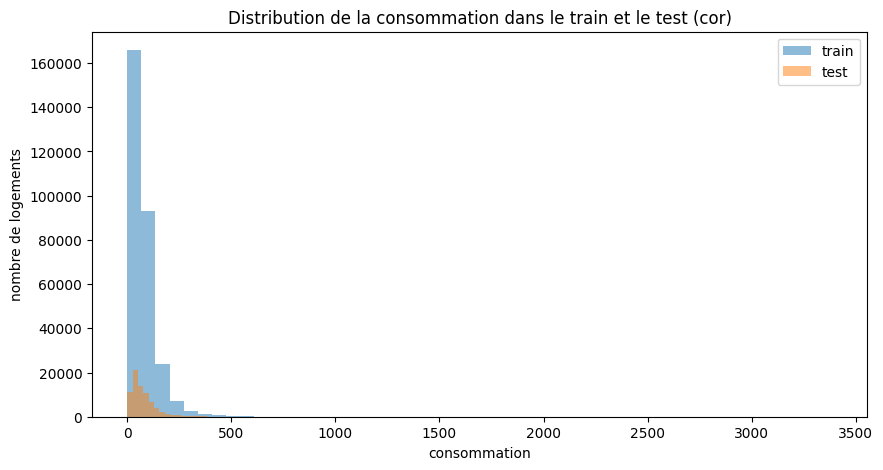

In [12]:
# graphique de la distribution de la consommation dans le train et le test
plt.figure(figsize=(10, 5))
plt.hist(y_train, bins=50, alpha=0.5, label='train')
plt.hist(y_test, bins=50, alpha=0.5, label='test')
plt.xlabel('consommation')
plt.ylabel('nombre de logements')
plt.title('Distribution de la consommation dans le train et le test (cor)')
plt.legend()
plt.savefig('../ressources/img/distribution_consommation_train_test_correlation_carla.png')
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# apprentissage du modèle 
DT = DecisionTreeRegressor()

mdl_dt = DT.fit(x_train, y_train)
y_pred = mdl_dt.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse, mape, r2_score(y_test, y_pred), root_mean_squared_error(y_test, y_pred)

ValueError: could not convert string to float: 'Installation de chauffage simple'

In [19]:
df.head(5)

,volume_stockage_generateur_ecs_ndeg1_ademe,conso_e_finale_installation_ecs_ademe,besoin_refroidissement_ademe,configuration_installation_chauffage_ndeg1_ademe,configuration_installation_ecs_ademe,type_installation_chauffage_ndeg1_ademe,coordonnee_cartographique_x_ban_ademe,nombre_niveau_logement_ademe,apports_internes_saison_froid_ademe,type_installation_ecs_general_ademe,...,qualite_isolation_plancher_haut_toit_terrase_ademe,categorie_enr_ademe,nombre_niveau_immeuble_ademe,appartement_non_visite_0_1_ademe,consommation_annuelle_totale_de_l_adresse_mwh_enedis_with_ban,type_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban,arrondissement,conso_kwh_m2
0,0.0,2621.9,0.0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,650709.85,1.0,0.0,individuel,...,<NA>,<NA>,7.0,<NA>,78.292,housenumber,2.328325,48.84874,6,22.762951
1,100.0,1153.0,0.0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,650709.85,1.0,0.0,individuel,...,<NA>,<NA>,7.0,<NA>,78.292,housenumber,2.328325,48.84874,6,212.195122
2,100.0,1772.3,0.0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,650709.85,1.0,0.0,individuel,...,<NA>,<NA>,7.0,<NA>,78.292,housenumber,2.328325,48.84874,6,22.550544
3,100.0,1150.6,0.0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,650709.85,1.0,0.0,individuel,...,<NA>,<NA>,7.0,<NA>,78.292,housenumber,2.328325,48.84874,6,214.285714
4,100.0,1132.2,0.0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,650709.85,1.0,0.0,individuel,...,<NA>,<NA>,7.0,<NA>,78.292,housenumber,2.328325,48.84874,6,231.382979
